# Communes for 2025

Plotting communes for targeting in 2025 framework revision

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [129]:
import unicodedata
import re
from io import BytesIO

import ocha_stratus as stratus
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from matplotlib.ticker import EngFormatter
from matplotlib.patches import Patch

from src.datasources import hydrosheds, codab, anadia
from src.blob_utils import PROJECT_PREFIX

In [3]:
# just for loading old local file into blob
# gdf_river = hydrosheds.load_niger_river(local=True)
# blob_name = f"{PROJECT_PREFIX}/processed/hydrosheds/niger_river.shp"
# stratus.upload_shp_to_blob(gdf_river, blob_name)

In [4]:
# codab.download_codab_to_blob()

In [5]:
adm3 = codab.load_codab_from_blob(admin_level=3, aoi_only=True)

In [6]:
adm3_all = codab.load_codab_from_blob(admin_level=3, aoi_only=False)

<Axes: >

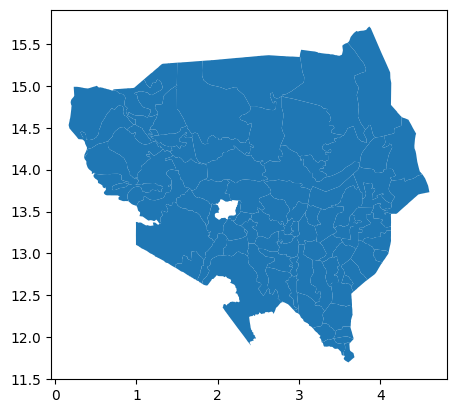

In [7]:
adm3.plot()

In [8]:
blob_name = f"{PROJECT_PREFIX}/processed/hydrosheds/niger_river.shp"
gdf_river = stratus.load_shp_from_blob(blob_name)

<Axes: >

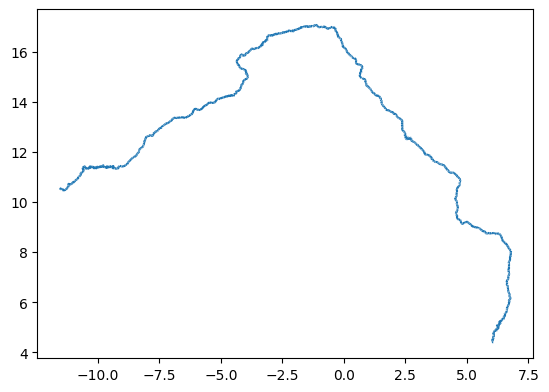

In [9]:
gdf_river.plot()

In [10]:
river_aoi = gpd.sjoin(gdf_river, adm3_all, how="inner", predicate="intersects")

In [11]:
adm3["niger_distance"] = (
    adm3.to_crs(3857).geometry.distance(gdf_river.to_crs(3857).union_all())
    / 1000
)

<Axes: >

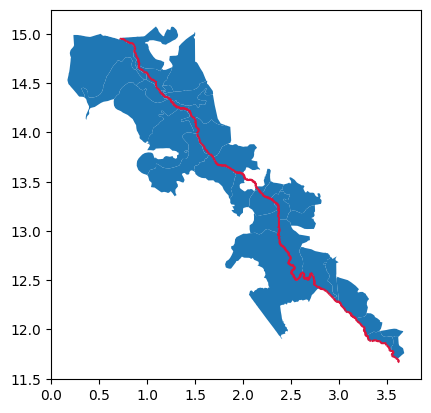

In [12]:
d_thresh = 10
adm3["along_niger"] = adm3["niger_distance"] <= d_thresh

fig, ax = plt.subplots()

adm3[adm3["along_niger"]].plot(ax=ax)
river_aoi.plot(ax=ax, color="crimson")

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_44050/969871726.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (adm3.geometry.centroid.x > lon)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_44050/969871726.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  & (adm3.geometry.centroid.y < lat)


<Axes: >

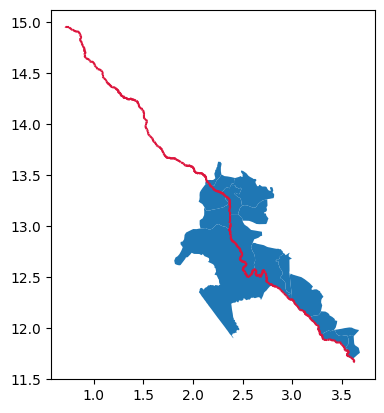

In [113]:
lon, lat = 2, 13.5
adm3["downstream"] = (
    (adm3.geometry.centroid.x > lon)
    & (adm3.geometry.centroid.y < lat)
    & (adm3["along_niger"])
)

fig, ax = plt.subplots()

adm3[adm3["downstream"]].plot(ax=ax)
river_aoi.plot(ax=ax, color="crimson")

In [105]:
blob_name = f"{PROJECT_PREFIX}/processed/hydrosheds/sirba_river_in_niger"
gdf_sirba = stratus.load_shp_from_blob(blob_name)

<Axes: >

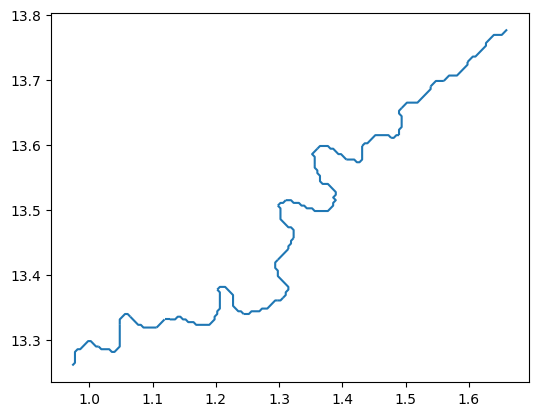

In [114]:
gdf_sirba.plot()

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_44050/803123274.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (adm3.geometry.centroid.x > lon)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_44050/803123274.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  & (adm3.geometry.centroid.y < lat)


<Axes: >

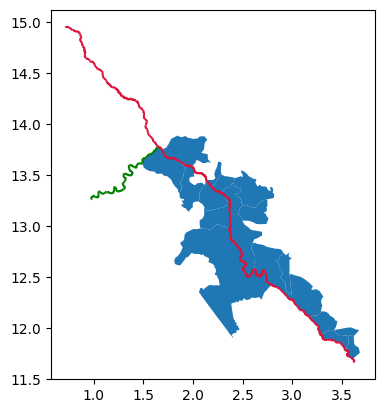

In [115]:
lon, lat = 1.5, 13.8
adm3["downstream_sirba"] = (
    (adm3.geometry.centroid.x > lon)
    & (adm3.geometry.centroid.y < lat)
    & (adm3["along_niger"])
)

fig, ax = plt.subplots()

adm3[adm3["downstream_sirba"]].plot(ax=ax)
gdf_sirba.plot(ax=ax, color="green")
river_aoi.plot(ax=ax, color="crimson")

In [14]:
# for loading old ANADIA data
df_anadia_old = anadia.load_processed_anadia(from_blob=True)

df_anadia_old_grouped = (
    df_anadia_old.groupby("ADM3_PCODE").sum(numeric_only=True).reset_index()
)

In [15]:
df_anadia_old_grouped

,ADM3_PCODE,idEvent,Pertes d'elevage (UBT),Pertes de cultures (ha),Personnes affectées,Maisons détruites,Pertes en vies humaines,Blessés,Pertes de vivres (tonnes),Cases détruites,...,Puits détruits,Boutiques détruites,Mosquées détruites,Barrages détruits,Digues détruites,Clases d'école détruites,Magasins détruits,Moulins à grain détruits,Postes radio détruits,Centres de santé détruits
0,NE003001001,131403.0,7.2,1814.70,13855.0,1350.0,0.0,0.0,0.000,67.0,...,9.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,NE003001002,39886.0,0.0,255.65,7416.0,493.0,1.0,0.0,0.000,242.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NE003001003,15654.0,0.0,0.00,835.0,0.0,0.0,0.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NE003001004,26033.0,0.0,0.05,1947.0,212.0,1.0,0.0,0.000,20.0,...,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,NE003001005,2091.0,0.0,24.00,72.0,20.0,0.0,0.0,0.000,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,NE006012005,41168.0,5.6,3129.05,12415.0,45.0,1.0,0.0,0.200,1.0,...,26.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,NE006012006,2818.0,0.0,1189.87,19502.0,0.0,0.0,0.0,0.000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85,NE006012007,30414.0,0.7,300.10,3232.0,248.0,0.0,0.0,0.000,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86,NE006013001,16260.0,1.2,553.50,2314.0,17.0,7.0,63.0,9.311,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
blob_name = f"{PROJECT_PREFIX}/processed/anadia/anadia_summary_2024.parquet"
df_anadia = stratus.load_parquet_from_blob(blob_name)
df_anadia_grouped = df_anadia.copy()

In [17]:
df_anadia_grouped

,Communes,1998-2024,freqMoy1998-2024,ADM3_PCODE
0,ABALA,88.0,3.384615,NE006001001
1,ABALAK,78.0,3.000000,NE005001001
2,ADERBISSINAT,111.0,4.269231,NE001001001
3,ADJEKORIA,45.0,1.730769,NE004003001
4,AFFALA,8.0,0.307692,NE005009001
...,...,...,...,...
271,ZINDER 1,164.0,6.307692,NE007011001
272,ZINDER 2,89.0,3.423077,NE007011002
273,ZINDER 3,81.0,3.115385,NE007011003
274,ZINDER 4,121.0,4.653846,NE007011004


In [45]:
blob_name = f"{PROJECT_PREFIX}/raw/ocha/Book1_fromDaniel.xlsx"
blob_data = stratus.load_blob_data(blob_name)

df_vuln = pd.read_excel(BytesIO(blob_data), skiprows=[0])
df_vuln = df_vuln.iloc[:-1]
df_vuln["Commune"] = df_vuln["Commune"].replace("Ayorou", "Ayerou")
df_vuln = df_vuln.merge(
    adm3.rename(columns={"ADM3_FR": "Commune"})[["Commune", "ADM3_PCODE"]]
)
int_cols = ["Vulnérables"]
df_vuln[int_cols] = df_vuln[int_cols].astype(int)
df_vuln

,N°,Région,Département,Commune,Degré de vulnérabilité,Acces sécuritaire,Accès physique,Acces,population,Vulnérables,...,PNUD,OMS,UNFPA,HCR,OIM,SAP,CRN,DMN,Totalt,ADM3_PCODE
0,1,DOSSO,Boboye,Fabidji,Moyennement,Accessible,Accessible,3.0,61826,42078,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003001002
1,2,DOSSO,Boboye,Fakara,Faiblement,Accessible,Accessible,3.0,29706,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003001003
2,3,DOSSO,Dosso,Sambéra,Faiblement,Accessible,Accessible,3.0,79126,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003004008
3,4,DOSSO,Falmey,Falmey,Extrêmement,Accessible,Accessible,3.0,116957,34511,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003005001
4,5,DOSSO,Falmey,Guilladjé,Moyennement,Accessible,Accessible,3.0,43842,17113,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003005002
5,6,DOSSO,Gaya,Gaya,Faiblement,Accessible,Accessible,3.0,99362,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,11.0,NE003006003
6,7,DOSSO,Gaya,Tanda,Faiblement,Accessible,Difficultés,2.0,77810,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,10.0,NE003006004
7,8,DOSSO,Gaya,Tounouga,Faiblement,Accessible,Difficultés,2.0,66713,0,...,1.0,1.0,1.0,1.0,NaN,1.0,NaN,1.0,10.0,NE003006005
8,9,TILLABERI,Ayerou,Ayerou,Moyennement,Difficultés,Accessible,2.0,51758,37760,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,10.0,NE006002001
9,10,TILLABERI,Gothèye,Dargol,Moyennement,Difficultés,Accessible,2.0,228125,81411,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,9.0,NE006007001


In [71]:
blob_name = f"{PROJECT_PREFIX}/raw/wfp/Communes_fleuve_niger.xlsx"
blob_data = stratus.load_blob_data(blob_name)
df_wfp = pd.read_excel(BytesIO(blob_data))
df_wfp["ADM3_PCODE"] = df_wfp["rowcacode3"].str.replace("R", "")
drop_cols = [
    "NOM_COM",
    "adm_01",
    "adm_02",
    "adm_03",
    "rowcacode1",
    "rowcacode2",
    "rowcacode3",
    "Shape_Leng",
    "Shape_Area",
    "ISO3",
    "ISO2",
]
df_wfp = df_wfp.drop(columns=drop_cols)

In [82]:
def wfp_rang_to_class(rang):
    if rang <= 6:
        return 1
    elif rang <= 11:
        return 2
    elif rang <= 28:
        return 3
    else:
        return None


df_wfp["priorisation"] = df_wfp["Rang"].apply(wfp_rang_to_class)

In [84]:
df_wfp

,Impact inondation,accessibilité,Accès sécuritaire,Vulnerabilité,TOTAL,Rang,ADM3_PCODE,priorisation
0,5,2,2,2,11,1,NE006010002,1
1,4,3,2,2,11,1,NE003004008,1
2,3,3,2,2,10,3,NE006012007,1
3,3,3,2,2,10,3,NE003006003,1
4,3,3,2,2,10,3,NE003006004,1
5,3,3,0,3,9,6,NE006012005,1
6,2,3,3,1,9,6,NE006008001,1
7,2,3,3,1,9,6,NE006008008,1
8,2,3,3,1,9,6,NE006008004,1
9,2,3,3,1,9,6,NE006008010,1


In [123]:
cols = [x for x in adm3 if "ADM" in x] + [
    "along_niger",
    "downstream",
    "downstream_sirba",
]
df_combine = (
    adm3[cols]
    .merge(df_vuln, how="left")
    .merge(df_anadia_grouped, how="left")
    .merge(df_anadia_old_grouped, how="left")
    .merge(df_wfp, how="left")
)

drop_cols = ["N°", "Région", "Département", "Commune", "Communes", "idEvent"]
df_combine = df_combine.drop(columns=drop_cols).rename(
    columns={
        "along_niger": "sur_fleuve",
        "downstream": "aval_de_niamey",
        "downstream_sirba": "aval_de_sirba",
    }
)
df_combine

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,sur_fleuve,aval_de_niamey,...,Moulins à grain détruits,Postes radio détruits,Centres de santé détruits,Impact inondation,accessibilité,Accès sécuritaire,Vulnerabilité,TOTAL,Rang,priorisation
0,Birni N'Gaouré,NE003001001,Boboye,NE003001,Dosso,NE003,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fabidji,NE003001002,Boboye,NE003001,Dosso,NE003,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fakara,NE003001003,Boboye,NE003001,Dosso,NE003,Niger (the),NE,True,True,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Harikanassou,NE003001004,Boboye,NE003001,Dosso,NE003,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kankandi,NE003001005,Boboye,NE003001,Dosso,NE003,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,Sakoïra,NE006012005,Tillabéri,NE006012,Tillabéri,NE006,Niger (the),NE,True,False,...,0.0,0.0,0.0,3.0,3.0,0.0,3.0,9.0,6.0,1.0
85,Sinder,NE006012006,Tillabéri,NE006012,Tillabéri,NE006,Niger (the),NE,True,False,...,0.0,0.0,0.0,5.0,1.0,0.0,1.0,7.0,17.0,3.0
86,Tillabéri,NE006012007,Tillabéri,NE006012,Tillabéri,NE006,Niger (the),NE,True,False,...,0.0,0.0,0.0,3.0,3.0,2.0,2.0,10.0,3.0,1.0
87,Makalondi,NE006013001,Torodi,NE006013,Tillabéri,NE006,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [124]:
[x for x in df_combine]

['ADM3_FR',
 'ADM3_PCODE',
 'ADM2_FR',
 'ADM2_PCODE',
 'ADM1_FR',
 'ADM1_PCODE',
 'ADM0_FR',
 'ADM0_PCODE',
 'sur_fleuve',
 'aval_de_niamey',
 'aval_de_sirba',
 'Degré de vulnérabilité',
 'Acces sécuritaire',
 'Accès physique',
 'Acces',
 'population',
 'Vulnérables',
 'PAM',
 'FAO',
 'UNICEF',
 'PNUD',
 'OMS',
 'UNFPA',
 'HCR',
 'OIM',
 'SAP',
 'CRN',
 'DMN',
 'Totalt',
 '1998-2024',
 'freqMoy1998-2024',
 "Pertes d'elevage (UBT)",
 'Pertes de cultures (ha)',
 'Personnes affectées',
 'Maisons détruites',
 'Pertes en vies humaines',
 'Blessés',
 'Pertes de vivres (tonnes)',
 'Cases détruites',
 'Greniers détruits',
 'Puits détruits',
 'Boutiques détruites',
 'Mosquées détruites',
 'Barrages détruits',
 'Digues détruites',
 "Clases d'école détruites",
 'Magasins détruits',
 'Moulins à grain détruits',
 'Postes radio détruits',
 'Centres de santé détruits',
 'Impact inondation',
 'accessibilité',
 'Accès sécuritaire\xa0',
 'Vulnerabilité',
 'TOTAL',
 'Rang',
 'priorisation']

In [125]:
df_combine.corr(numeric_only=True)["TOTAL"]

sur_fleuve                        NaN
aval_de_niamey              -0.047840
aval_de_sirba                0.096424
Acces                        0.116377
Vulnérables                 -0.230258
PAM                         -0.203721
FAO                          0.361158
UNICEF                       0.085749
PNUD                        -0.007748
OMS                               NaN
UNFPA                       -0.019742
HCR                          0.046300
OIM                          0.149071
SAP                               NaN
CRN                               NaN
DMN                               NaN
Totalt                       0.161029
1998-2024                    0.614064
freqMoy1998-2024             0.614064
Pertes d'elevage (UBT)      -0.216723
Pertes de cultures (ha)      0.222048
Personnes affectées          0.351121
Maisons détruites            0.236512
Pertes en vies humaines      0.209138
Blessés                      0.001686
Pertes de vivres (tonnes)    0.135771
Cases détrui

In [152]:
ordered_priority = [
    "Première catégorie",
    "Deuxième catégorie",
    "Troisième catégorie",
    "Non classé",
]
priority_map = {
    1: "Première catégorie",
    2: "Deuxième catégorie",
    3: "Troisième catégorie",
    None: "Non classé",
}
color_map = {
    "Première catégorie": "green",
    "Deuxième catégorie": "gold",
    "Troisième catégorie": "crimson",
    "Non classé": "grey",
}

In [178]:
def plot_targeting_scatter(xcol, ycol):
    fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

    df_plot = df_combine[df_combine["sur_fleuve"]]
    df_plot.loc[:, [xcol, ycol]] = df_plot[[xcol, ycol]].fillna(0)
    df_plot.plot.scatter(y=ycol, x=xcol, ax=ax, marker="")

    legend_entries = {}
    for name, row in df_plot.set_index("ADM3_FR").iterrows():
        priority_word = priority_map.get(row["priorisation"], "Non classé")
        color = color_map[priority_word]
        zorder = 1 if priority_word != "Non classé" else 0
        fontweight = "bold" if row["aval_de_niamey"] else "normal"

        ax.annotate(
            name,
            row[[xcol, ycol]],
            rotation=45,
            fontsize=6,
            color=color,
            zorder=zorder,
            fontweight=fontweight,
            ha="center",
            va="center",
        )

        # Track legend entries
        if priority_word not in legend_entries:
            legend_entries[priority_word] = Patch(
                color=color, label=priority_word
            )
    ax.xaxis.set_major_formatter(EngFormatter(sep=""))
    ax.yaxis.set_major_formatter(EngFormatter(sep=""))

    ax.set_title(
        "Identification de communes dans Tillabéri et Dosso\n"
        "Noms en $\\bf{gras}$ : communes en aval du Sirba"
    )

    legend_patches = [
        legend_entries[p] for p in ordered_priority if p in legend_entries
    ]
    ax.legend(handles=legend_patches, title="Prioritisation PAM")

    [ax.spines[x].set_visible(False) for x in ["top", "right"]]
    return fig, ax

Text(0.5, 0, 'Fréquence moyenne des inondations (1998-2024)')

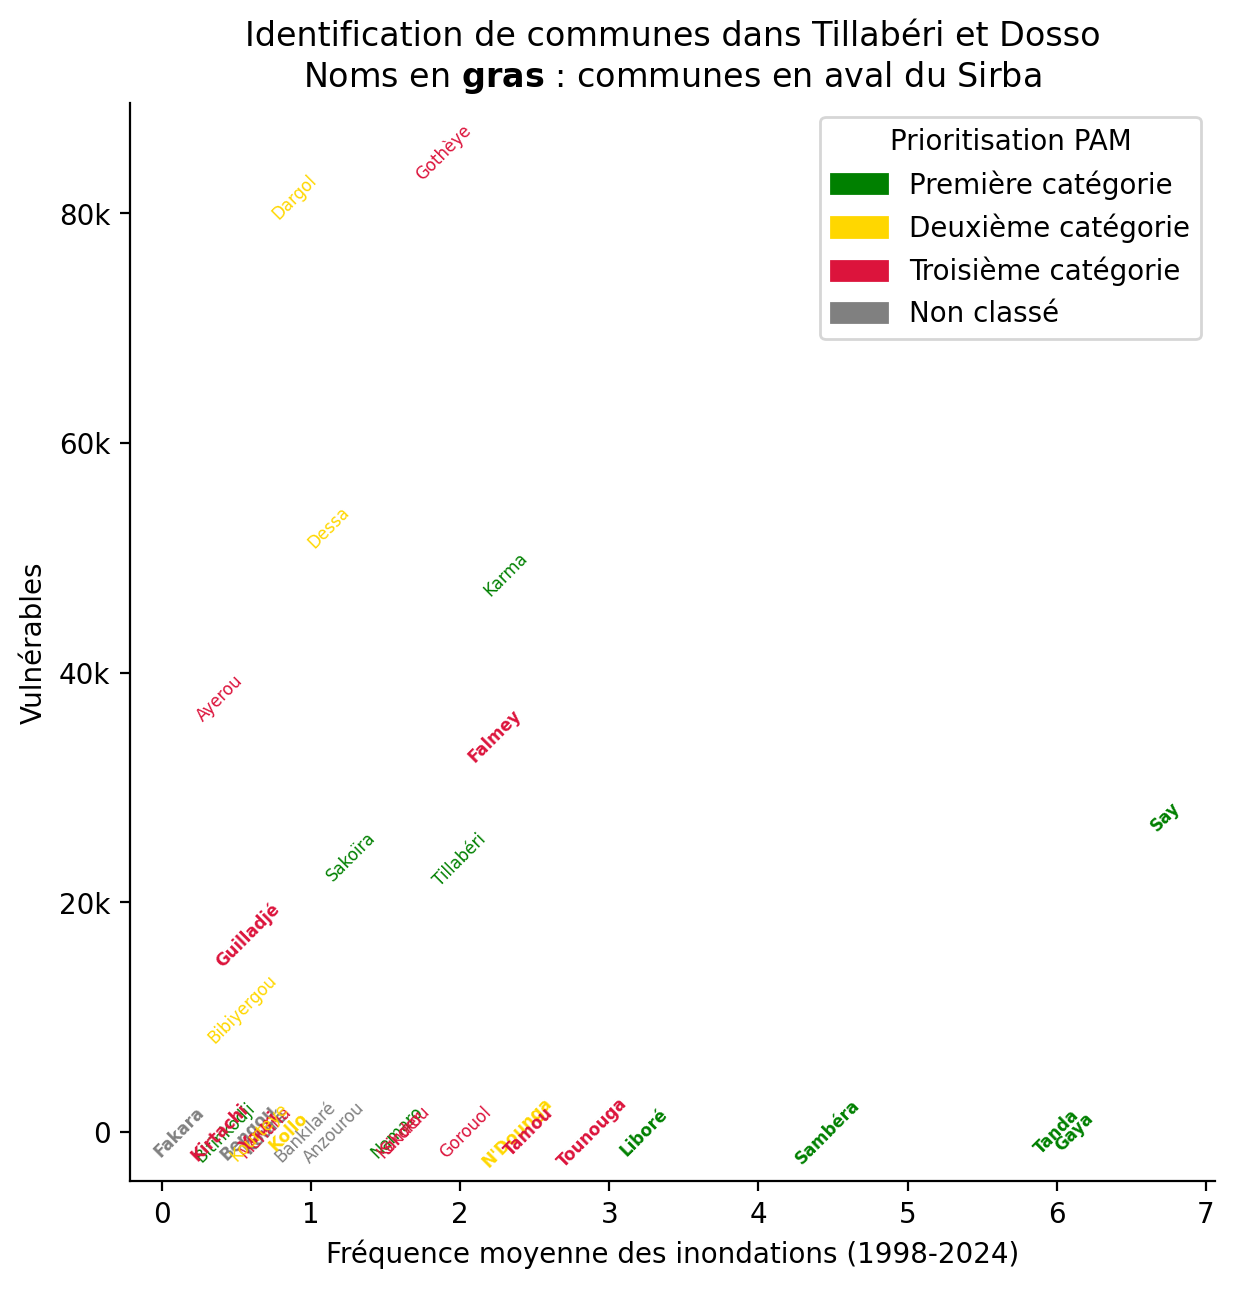

In [179]:
fig, ax = plot_targeting_scatter("freqMoy1998-2024", "Vulnérables")
ax.set_xlabel("Fréquence moyenne des inondations (1998-2024)")

Text(0.5, 0, 'Maisons détruites (total 1998-2020)')

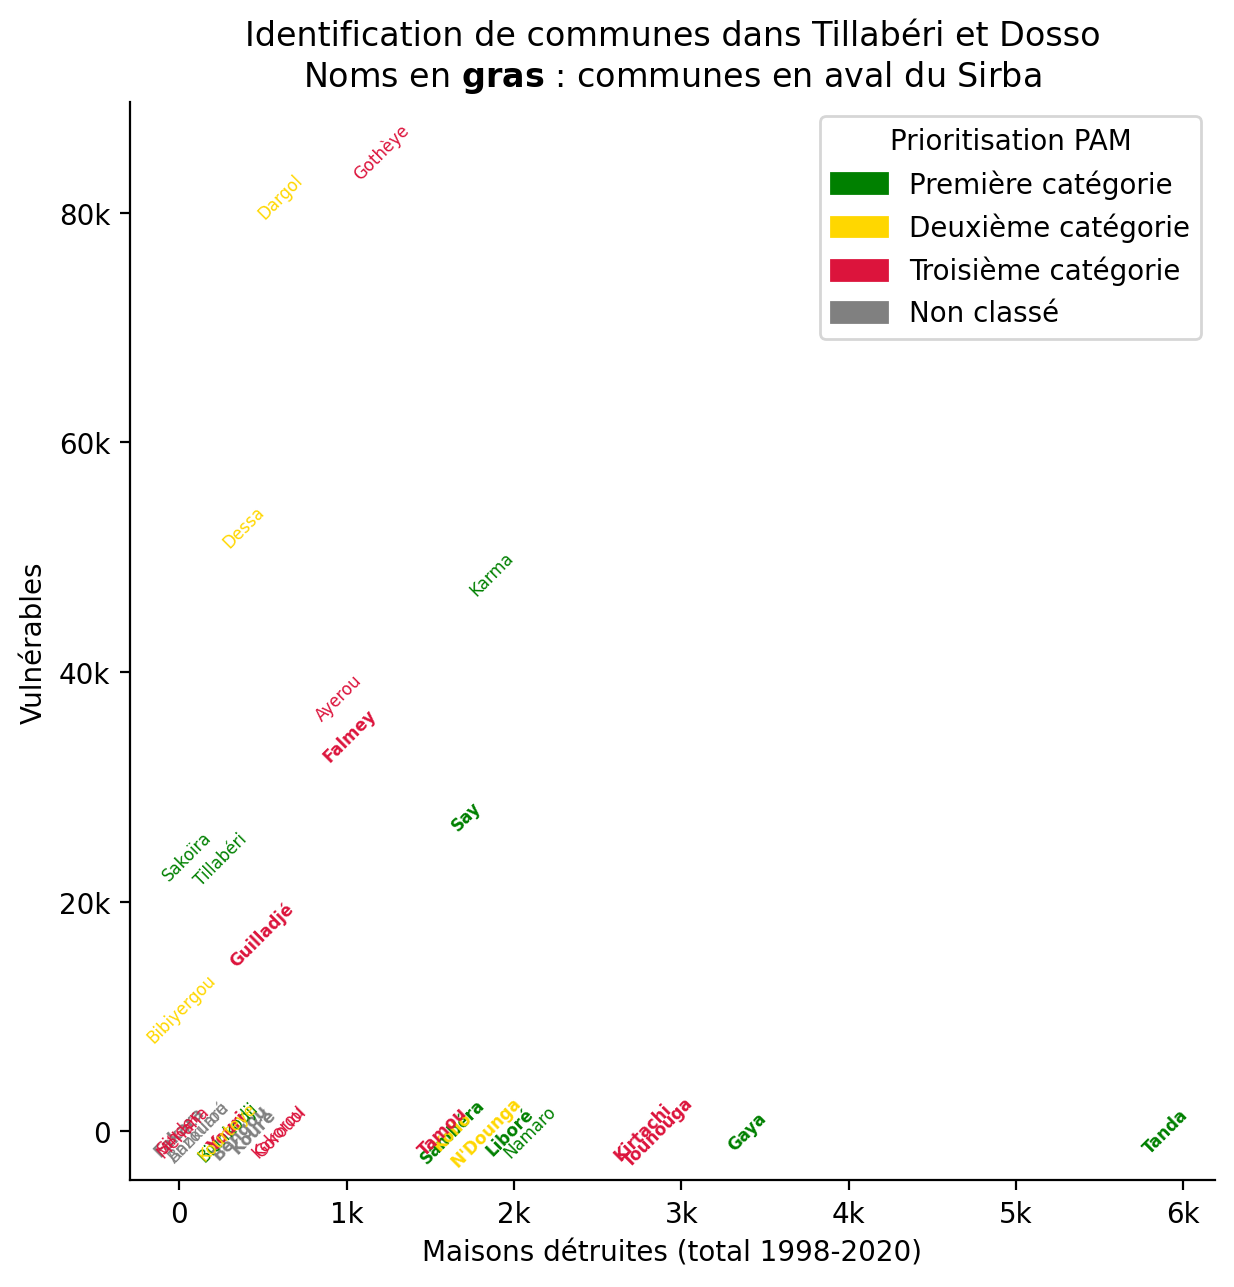

In [180]:
fig, ax = plot_targeting_scatter("Maisons détruites", "Vulnérables")
ax.set_xlabel("Maisons détruites (total 1998-2020)")

Text(0.5, 0, 'Personnes affectées (total 1998-2020)')

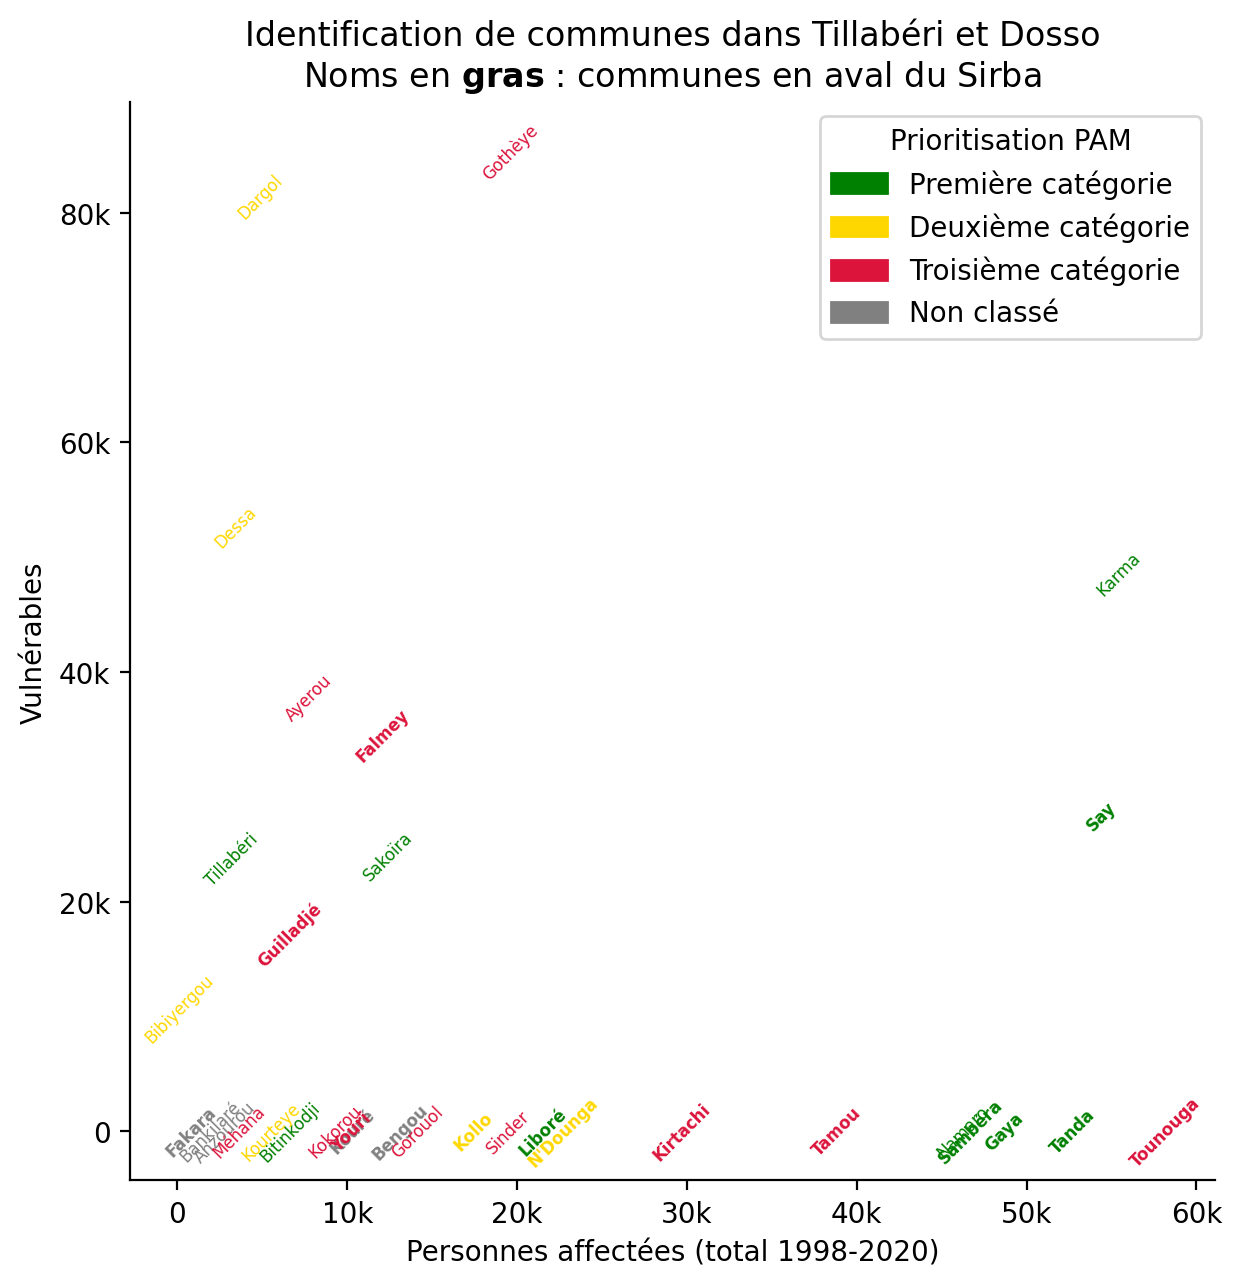

In [181]:
fig, ax = plot_targeting_scatter("Personnes affectées", "Vulnérables")
ax.set_xlabel("Personnes affectées (total 1998-2020)")

Text(0, 0.5, 'Maisons détruites (total 1998-2020)')

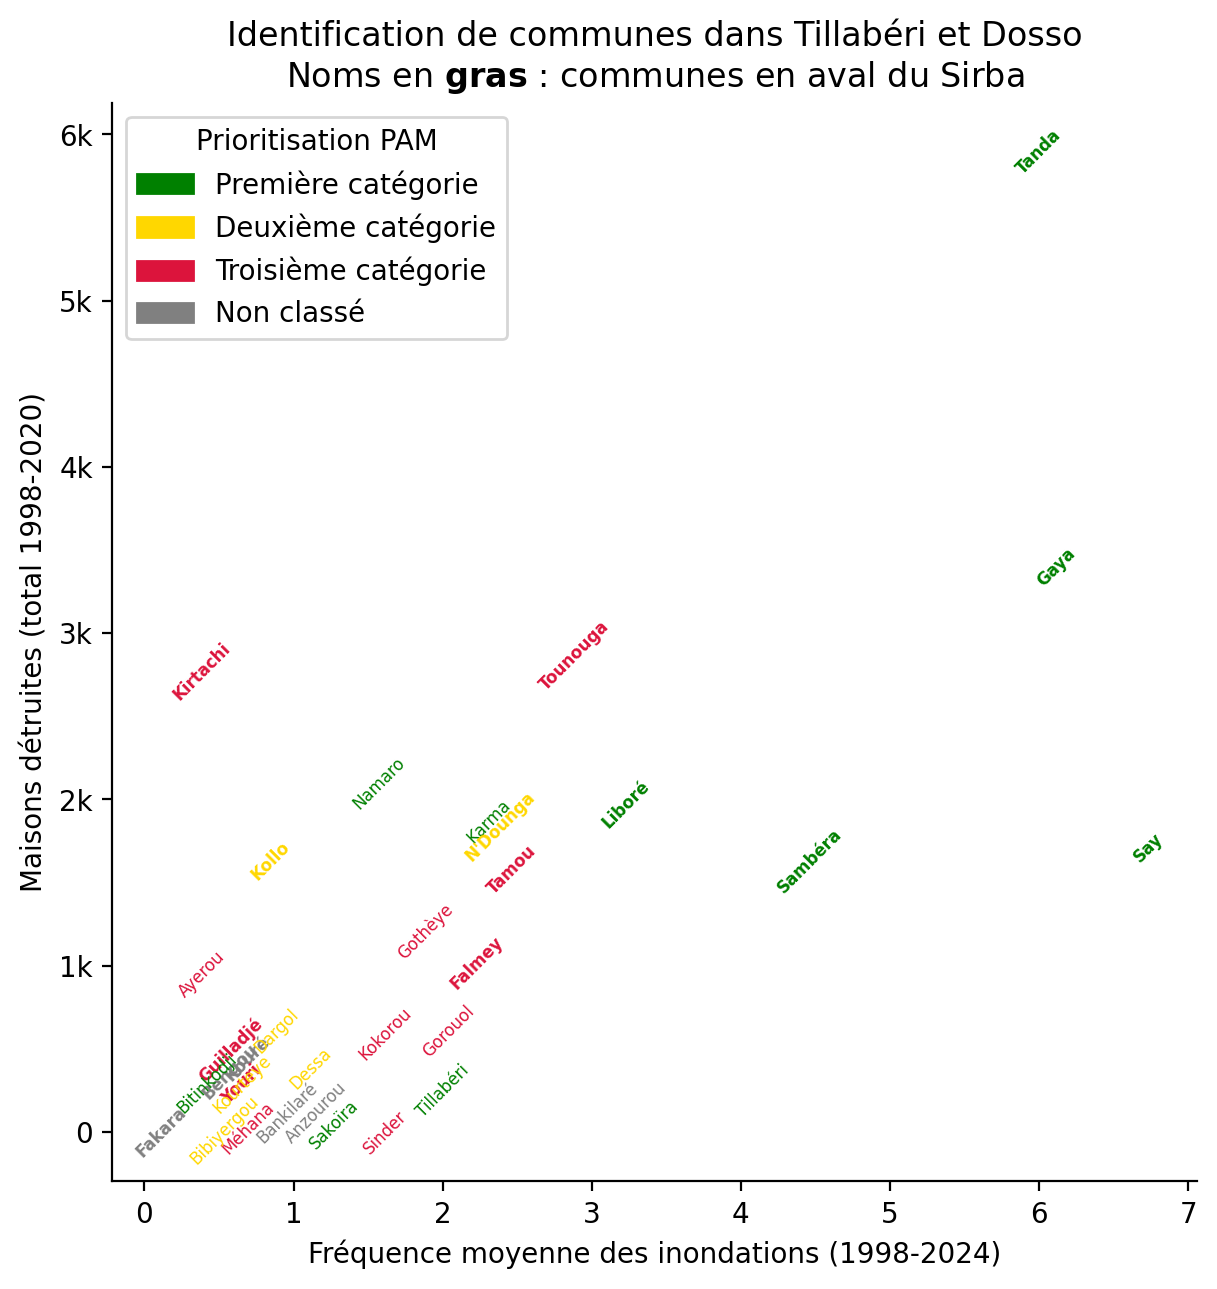

In [182]:
fig, ax = plot_targeting_scatter("freqMoy1998-2024", "Maisons détruites")
ax.set_xlabel("Fréquence moyenne des inondations (1998-2024)")
ax.set_ylabel("Maisons détruites (total 1998-2020)")

(-0.009409360700000008,
 3.8551075086999997,
 11.494016741449299,
 15.246481762883366)

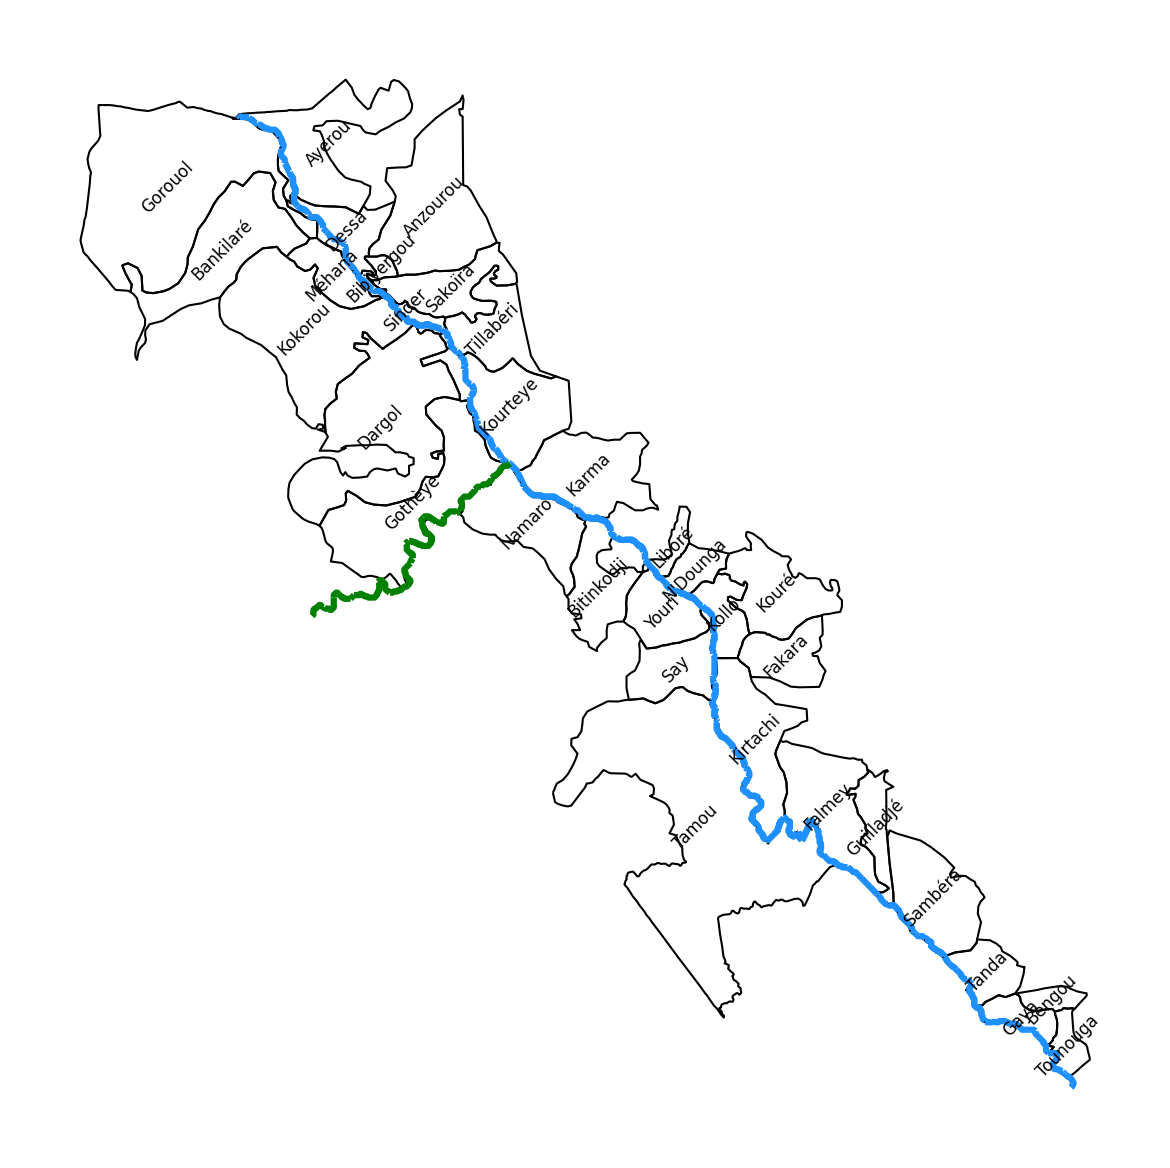

In [183]:
fig, ax = plt.subplots(dpi=300)

gdf_plot = adm3[["ADM3_PCODE", "geometry"]].merge(
    df_combine[df_combine["sur_fleuve"]]
)

gdf_plot.boundary.plot(ax=ax, linewidth=0.5, color="k")

for name, row in gdf_plot.set_index("ADM3_FR").iterrows():
    ax.annotate(
        name,
        (row["geometry"].centroid.x, row["geometry"].centroid.y),
        ha="center",
        va="center",
        fontsize=4,
        rotation=45,
    )

river_aoi.plot(ax=ax, color="dodgerblue")
gdf_sirba.plot(ax=ax, color="green")
ax.axis("off")

In [184]:
blob_name = f"{PROJECT_PREFIX}/processed/targeting_2025.csv"
stratus.upload_csv_to_blob(df_combine, blob_name)

In [185]:
def remove_accents(text):
    if isinstance(text, str):
        return "".join(
            c
            for c in unicodedata.normalize("NFKD", text)
            if not unicodedata.combining(c)
        )
    return text


def normalize_df(df):
    # Remove accents from column names
    df.columns = [remove_accents(col) for col in df.columns]

    # Remove accents from string entries in object or string columns
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].apply(remove_accents)

    return df

In [186]:
# remove accents because this messses up some CSVs
df_combine_clean = normalize_df(df_combine)
df_combine_clean

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,sur_fleuve,aval_de_niamey,...,Moulins a grain detruits,Postes radio detruits,Centres de sante detruits,Impact inondation,accessibilite,Acces securitaire,Vulnerabilite,TOTAL,Rang,priorisation
0,Birni N'Gaoure,NE003001001,Boboye,NE003001,Dosso,NE003,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fabidji,NE003001002,Boboye,NE003001,Dosso,NE003,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fakara,NE003001003,Boboye,NE003001,Dosso,NE003,Niger (the),NE,True,True,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Harikanassou,NE003001004,Boboye,NE003001,Dosso,NE003,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kankandi,NE003001005,Boboye,NE003001,Dosso,NE003,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,Sakoira,NE006012005,Tillaberi,NE006012,Tillaberi,NE006,Niger (the),NE,True,False,...,0.0,0.0,0.0,3.0,3.0,0.0,3.0,9.0,6.0,1.0
85,Sinder,NE006012006,Tillaberi,NE006012,Tillaberi,NE006,Niger (the),NE,True,False,...,0.0,0.0,0.0,5.0,1.0,0.0,1.0,7.0,17.0,3.0
86,Tillaberi,NE006012007,Tillaberi,NE006012,Tillaberi,NE006,Niger (the),NE,True,False,...,0.0,0.0,0.0,3.0,3.0,2.0,2.0,10.0,3.0,1.0
87,Makalondi,NE006013001,Torodi,NE006013,Tillaberi,NE006,Niger (the),NE,False,False,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [187]:
filename = "targeting_2025_clean.csv"
savepath = f"temp/{filename}"
df_combine_clean.to_csv(savepath, index=False)

blob_name = f"{PROJECT_PREFIX}/processed/{filename}"
stratus.upload_csv_to_blob(df_combine_clean, blob_name)